## Overview

Objective:


*   Generate data visualization from middle mile fleet utilization dataset

To do:

1.   Data Manipulation
      *   Standarize column names
          
          **Resolution**: Set the columns into lower case and replace '-' into '_' to make it readable.
      *   Convert data type

          **Resolution**: Convert 'delivery_date' column to datetime and values columns to integer.

2.   Create Reusable Function:
      *   Filter Dataframe: To filter dataframe based on selected_columns and selected_hubs values.
      *   Assign column by condition: To create a new column based on condition. It is used for create new columns to map vehicle type and its max tonnage for each row.
      * Calculate utilization rate: To calculate total order weight divided by max tonnage for every row.
      * Subplots: To generate subplots to visualize the data periodicaly using line chart based on arguments inputed.

Final Result:

Data visualization that show the utilization rate of middle mile fleet. The generated visualization can be used for the reference to evaluate if any vehicle type are not utilized optimally and seek for the better fit if needed based on operational and strategic planning.









## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
from matplotlib.ticker import MaxNLocator
import math
import seaborn as sns

## Import Data

In [2]:
sheet_id = '1ANGLzIIYiJzk1-dfyomPbYlHSUzZQt5tauJOIY-EdeA'
sheet_name = 'raw_data'

gsheet_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}'

df = pd.read_csv(gsheet_url)
df_backup = df.copy(deep=True)

## Check Data

In [3]:
df.head()

,delivery_date,hubs,order_no slot-0,order_no slot-1,order_no slot-2,order_no slot-sameday,slot-0 total_weight_perorder,slot-1 total_weight_perorder,slot-2 total_weight_perorder,slot-sameday total_weight_perorder,week,month
0,2026-01-01,Beji - Depok,NaN,NaN,58.0,14.0,NaN,NaN,303.0,86.0,1,1
1,2026-01-01,Bekasi - CIBUBUR,NaN,NaN,53.0,16.0,NaN,NaN,297.0,83.0,1,1
2,2026-01-01,Bintaro - TANGSEL,NaN,NaN,48.0,5.0,NaN,NaN,300.0,29.0,1,1
3,2026-01-01,Cibitung - KAB BEKASI,NaN,NaN,61.0,24.0,NaN,NaN,250.0,126.0,1,1
4,2026-01-01,Karawaci - TANGERANG,NaN,NaN,46.0,13.0,NaN,NaN,256.0,78.0,1,1


In [4]:
print(df.columns)

Index(['delivery_date', 'hubs', 'order_no slot-0', 'order_no slot-1',
       'order_no slot-2', 'order_no slot-sameday',
       'slot-0 total_weight_perorder', 'slot-1 total_weight_perorder',
       'slot-2 total_weight_perorder', 'slot-sameday total_weight_perorder',
       'week', 'month'],
      dtype='object')


In [5]:
df.dtypes

,0
delivery_date,object
hubs,object
order_no slot-0,float64
order_no slot-1,float64
order_no slot-2,float64
order_no slot-sameday,float64
slot-0 total_weight_perorder,float64
slot-1 total_weight_perorder,float64
slot-2 total_weight_perorder,float64
slot-sameday total_weight_perorder,float64


## Data Manipulation

### Standarize column names

In [6]:
df.columns = df.columns.str.lower()
# Fill white spaces with _
df.columns = df.columns.str.replace(' ', '_').str.replace('-', '_')

### Convert Data Type

In [7]:
# Convert 'delivery_date' to datetime objects
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

# Create a list to convert multiple columns
cols_to_convert = [
    'order_no_slot_0',
    'order_no_slot_1',
    'order_no_slot_2',
    'order_no_slot_sameday',
    'slot_0_total_weight_perorder',
    'slot_1_total_weight_perorder',
    'slot_2_total_weight_perorder',
    'slot_sameday_total_weight_perorder'
       ]

# Fill NAN values with 0
df[cols_to_convert] = df[cols_to_convert].fillna(0)

# Convert columns data type to integer
df[cols_to_convert] = df[cols_to_convert].astype(int)

In [8]:
df

,delivery_date,hubs,order_no_slot_0,order_no_slot_1,order_no_slot_2,order_no_slot_sameday,slot_0_total_weight_perorder,slot_1_total_weight_perorder,slot_2_total_weight_perorder,slot_sameday_total_weight_perorder,week,month
0,2026-01-01,Beji - Depok,0,0,58,14,0,0,303,86,1,1
1,2026-01-01,Bekasi - CIBUBUR,0,0,53,16,0,0,297,83,1,1
2,2026-01-01,Bintaro - TANGSEL,0,0,48,5,0,0,300,29,1,1
3,2026-01-01,Cibitung - KAB BEKASI,0,0,61,24,0,0,250,126,1,1
4,2026-01-01,Karawaci - TANGERANG,0,0,46,13,0,0,256,78,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
927,2026-03-19,Pejaten - JAKSEL,80,75,0,0,338,275,0,0,12,3
928,2026-03-19,Pondok Kopi - JAKTIM,61,33,37,44,304,165,169,192,12,3
929,2026-03-19,Satellite HUB Bogor,61,36,0,0,293,148,0,0,12,3
930,2026-03-19,Satellite HUB Karawaci,35,10,0,0,158,41,0,0,12,3


## Function

### Filter Dataframe

In [9]:
def filter_dataframe(df_to_filter, selected_columns, selected_hubs):
    """
    Filters a DataFrame based on selected columns and hub values.

    Args:
        df_to_filter (pd.DataFrame): The input DataFrame to be filtered.
        selected_columns (list): A list of column names to select from the DataFrame.
        selected_hubs (list): A list of hub names to filter the DataFrame by.

    Returns:
        pd.DataFrame: A new DataFrame containing only the selected columns and rows
                      where the 'hubs' column matches one of the `selected_hubs`.
    """
    # Filter the DataFrame based on selected columns
    filtered_df = df_to_filter[selected_columns].copy()

    # Further filter by selected hubs
    filtered_df = filtered_df[filtered_df['hubs'].isin(selected_hubs)]

    return filtered_df

### Assign column by condition

In [10]:
def assign_column_from_map(df, source_column, new_column_name, mapping_dict, default_value):
    """
    Assigns a new column to a DataFrame based on a mapping from an existing column.

    Args:
        df (pd.DataFrame): The input DataFrame.
        source_column (str): The name of the column to map from.
        new_column_name (str): The name of the new column to create.
        mapping_dict (dict): A dictionary where keys are values from the source_column
                             and values are the corresponding values for the new column.
        default_value: The value to use for entries in the source_column that are not
                       found in the mapping_dict.

    Returns:
        pd.DataFrame: The DataFrame with the new column added.
    """
    df[new_column_name] = df[source_column].map(mapping_dict).fillna(default_value)
    return df

### Calculate Ulitization rate

In [11]:
def calculate_utilization_rate(df, weight_column, max_tonnage_column, new_column_name):
  """
  Calculates the utilization rate based on a weight column and a maximum tonnage column.

  Args:
      df (pd.DataFrame): The input DataFrame.
      weight_column (str): The name of the column containing the actual weight.
      max_tonnage_column (str): The name of the column containing the maximum tonnage capacity.
      new_column_name (str): The name of the new column to store the calculated utilization rate.

  Returns:
      pd.DataFrame: The DataFrame with the new 'utilization_rate' column added.
  """
  df[new_column_name] = ((df[weight_column] / df[max_tonnage_column])*100).round(2)
  return df

### Subplots Single Time Slot

In [12]:
def utilization_rate_subplots(df, time_slot, start_period, time_index_column, values_column, agg_method='mean'):
  """
  Generates a grid of line plots to visualize utilization rates or other metrics for different hubs over a specified time period.

  Each subplot represents a different hub, showing the trend of the chosen `values_column`
  (e.g., utilization rate, total orders, total weight) over time.

  Args:
      df (pd.DataFrame): The input DataFrame containing the data to be visualized.
      time_slot (str): A string describing the time slot (e.g., 'slot-batching', 'slot-2')
                       to be included in the plot's main title.
      start_period (int): The starting period for the x-axis. If `time_index_column` is 'week' or 'month',
                          it's the numeric label. If 'delivery_date', it's the number of days back
                          from the latest date.
      time_index_column (str): The column to use as the time index for the x-axis.
                               Can be 'week', 'month', or 'delivery_date'.
      values_column (str): The column containing the numerical values to be plotted on the y-axis
                           (e.g., 'utilization_rate', 'total_order', 'total_weight').
      agg_method (str, optional): The aggregation method to apply to `values_column` (e.g., 'mean', 'sum').
                                  Defaults to 'mean'.

  Returns:
      None: This function displays plots directly and does not return a value.
  """
  # Aggregate data by hub and time index, then unstack
  utilization_rate_subplots_df = df.groupby(['hubs', time_index_column])[values_column].agg(agg_method).unstack()

  # Handle slicing based on time_index_column
  if time_index_column == 'delivery_date':
      # Ensure columns are datetime objects for proper slicing
      utilization_rate_subplots_df.columns = pd.to_datetime(utilization_rate_subplots_df.columns)
      # Calculate the date range for the last 'start_period' days
      end_date = utilization_rate_subplots_df.columns.max()
      start_date = end_date - pd.Timedelta(days=start_period)
      utilization_rate_subplots_df = utilization_rate_subplots_df.loc[:, start_date:end_date]
  else:
      # For 'week' or 'month', slice directly by the numeric label
      utilization_rate_subplots_df = utilization_rate_subplots_df.loc[:, start_period:]

  # Convert aggregated values to integers
  utilization_rate_subplots_df = utilization_rate_subplots_df.astype(int)

  # Determine grid dimensions for subplots
  n_hubs = len(utilization_rate_subplots_df)
  n_cols = math.ceil(n_hubs ** 0.5)
  n_rows = math.ceil(n_hubs / n_cols)

  # Function to get a clear label for the time period (e.g., 'Weekly', 'Monthly', 'Daily')
  def get_time_period_label(time_index_column):
    if time_index_column == 'week':
      return 'Weekly'
    elif time_index_column == 'month':
      return 'Monthly'
    elif time_index_column == 'delivery_date':
      return 'Daily'
    return 'Period' # Default

  time_period_label = get_time_period_label(time_index_column)

  # Determine appropriate Y-axis label based on the values being plotted
  y_label_text = f'Average {time_period_label} Value'
  if 'utilization' in values_column or 'rate' in values_column:
      y_label_text = f'Average {time_period_label} Utilization Rate'
  elif 'weight' in values_column:
      y_label_text = f'Average {time_period_label} Weight (kg)'
  elif 'order' in values_column:
      y_label_text = f'Average {time_period_label} Order'

  # Initialize the figure and subplots
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
  axes_flat = axes.flatten() # Flatten axes for easy iteration

  # Calculate the overall maximum y_value across all hubs for setting shared y-axis limit
  overall_max_y_value = utilization_rate_subplots_df.values.max() if not utilization_rate_subplots_df.empty else 0

  # Set dynamic Y-axis limit for all subplots
  global_y_max = 100 if ('utilization' in values_column or 'rate' in values_column) else (overall_max_y_value * 1.2 if overall_max_y_value > 0 else None)

  # Loop through each subplot and plot the data for each hub
  for ax, hub_name in zip(axes_flat, utilization_rate_subplots_df.index):

      # Get data for the current hub
      data = utilization_rate_subplots_df.loc[hub_name]
      x_values = data.index
      y_values = data.values

      # Plot the data as a line graph
      ax.plot(x_values, y_values, marker='o', color='#22601C')

      # Function to get time period label for axis (e.g., 'Week', 'Month', 'Date')
      def get_time_period_label_for_axis(time_index_column):
          if time_index_column == 'week':
            return 'Week'
          elif time_index_column == 'month':
            return 'Month'
          elif time_index_column == 'delivery_date':
            return 'Date'
          return 'Period'

      time_period_for_axis_label = get_time_period_label_for_axis(time_index_column)

      # Set axes properties with the global y_max
      ax.set(title=hub_name, xlabel=f'{time_period_for_axis_label}', ylabel=y_label_text, xticks=x_values, ylim=(0, global_y_max))
      ax.grid(True, alpha=0.5)

      # Function to set X-axis rotation based on time_index_column inputted
      def set_x_axis_period_label(time_index_column):
        if time_index_column == 'delivery_date':
          return ax.tick_params(axis='x', rotation=45)
        else:
            return ax.tick_params(axis='x', rotation=0)

      set_x_axis_period_label = set_x_axis_period_label(time_index_column)

      # Ensure Y-axis ticks are integers
      ax.yaxis.set_major_locator(MaxNLocator(integer=True))

      # Add annotations to each data point
      for x, y in data.items():
          annotation_text = str(y) # Default annotation

          if 'utilization' in values_column or 'rate' in values_column:
              annotation_text = f"{int(y)}%"
          else: # For raw weights or orders
              annotation_text = f"{int(y)}"

          # Position annotation slightly above the data point
          ax.annotate(text=annotation_text, xy=(x, y), xytext=(0, 8),
                      textcoords='offset points', ha='center')

  # Hide any unused subplots
  for ax in axes_flat[n_hubs:]:
      ax.axis('off')

  # Set the main title for the entire figure
  fig_title_text = f'{time_period_label} {y_label_text.replace(f"Average {time_period_label} ", "")} {time_slot}'
  fig.suptitle(fig_title_text, fontsize= 16, fontweight= 'bold', ha = 'center', y=1)

  plt.tight_layout()
  plt.show()

### Subplots Multiple Time Slot

In [13]:
def plot_multi_timeslot_utilization(dataframes_dict, time_index_column='week', time_delta=8, values_column='utilization_rate', agg_method='mean'):
    """
    Generates a comparative visualization of utilization rates for multiple time slots
    across different hubs.

    Args:
        dataframes_dict (dict): A dictionary where keys are time slot names (str)
                                and values are their corresponding DataFrames (pd.DataFrame).
        time_index_column (str): The column to use as the time index for the x-axis.
                                 Can be 'week', 'month', or 'delivery_date'.
        time_delta (int): The starting period for the x-axis. If `time_index_column` is 'week' or 'month',
                            it's the numeric label. If 'delivery_date', it's the number of days back
                            from the latest date.
        values_column (str): The column containing the numerical values to be plotted on the y-axis
                             (e.g., 'utilization_rate', 'total_order', 'total_weight').
        agg_method (str, optional): The aggregation method to apply to `values_column` (e.g., 'mean', 'sum').
                                    Defaults to 'mean'.

    Returns:
        None: This function displays plots directly and does not return a value.
    """

    processed_dfs = []
    for time_slot_name, df in dataframes_dict.items():
        df_copy = df.copy()
        df_copy['time_slot'] = time_slot_name
        processed_dfs.append(df_copy)
    combined_df = pd.concat(processed_dfs, ignore_index=True)

    # Apply filtering based on time_delta to combined_df
    if time_index_column == 'delivery_date':
        combined_df[time_index_column] = pd.to_datetime(combined_df[time_index_column])
        end_date_filter = combined_df[time_index_column].max()
        start_date_filter = end_date_filter - pd.Timedelta(days=time_delta - 1)
        combined_df = combined_df[combined_df[time_index_column] >= start_date_filter]
    else: # For 'week' or 'month'
        end_period = combined_df[time_index_column].max()
        start_period = end_period - time_delta
        combined_df = combined_df[combined_df[time_index_column] > start_period]

    grouped_df = combined_df.groupby(['hubs', time_index_column, 'time_slot'])[values_column].agg(agg_method).unstack()

    # Fill NaN values (introduced by unstacking missing combinations) with 0, then convert to int for plotting
    grouped_df = grouped_df.fillna(0).astype(int)

    unique_hubs = grouped_df.index.get_level_values('hubs').unique()
    n_hubs = len(unique_hubs)
    n_cols = math.ceil(n_hubs ** 0.5)
    n_rows = math.ceil(n_hubs / n_cols)

    def get_time_period_label(time_index_column):
        if time_index_column == 'week':
            return 'Weekly'
        elif time_index_column == 'month':
            return 'Monthly'
        elif time_index_column == 'delivery_date':
            return 'Daily'
        return 'Period'

    time_period_label = get_time_period_label(time_index_column)

    y_label_text = f'Average {time_period_label} Value'
    if 'utilization' in values_column or 'rate' in values_column:
        y_label_text = f'Average {time_period_label} Utilization Rate (%)'
    elif 'weight' in values_column:
        y_label_text = f'Average {time_period_label} Weight (kg)'
    elif 'order' in values_column:
        y_label_text = f'Average {time_period_label} Order'

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
    axes_flat = axes.flatten()

    overall_max_y_value = grouped_df.values.max() if not grouped_df.empty else 0
    global_y_max = 100 if ('utilization' in values_column or 'rate' in values_column) else (overall_max_y_value * 1.2 if overall_max_y_value > 0 else 100)

    # Update this line to use matplotlib.colormaps
    colors = plt.colormaps['tab10']
    color_map = {slot: colors(i) for i, slot in enumerate(dataframes_dict.keys())}

    for ax, hub_name in zip(axes_flat, unique_hubs):
        hub_data = grouped_df.loc[hub_name]

        x_values_for_ticks = hub_data.index.get_level_values(time_index_column).unique()

        for i, (slot_name, color) in enumerate(color_map.items()):
            if slot_name in hub_data.columns:
                x_values = hub_data.index.get_level_values(time_index_column)
                y_values = hub_data[slot_name]

                # Conditional check to skip plotting if all y_values are 0
                if y_values.sum() == 0:
                    continue # Skip plotting if all utilization values are zero

                ax.plot(x_values, y_values, marker='o', label=slot_name, color=color)

                for x, y in zip(x_values, y_values):
                    annotation_text = str(y)
                    if 'utilization' in values_column or 'rate' in values_column:
                        annotation_text = f"{int(y)}%"
                    else:
                        annotation_text = f"{int(y)}"

                    # Adjust xytext based on the line index to prevent overlap
                    # For this step, let's keep xytext simple as (0,8) and focus on yticks, as fine-tuning annotation positioning
                    # might require more complex logic (e.g., dynamic offset based on value and neighboring points)
                    ax.annotate(text=annotation_text, xy=(x, y), xytext=(0, 8), # Keep it simple for now, as dynamic positioning is complex.
                                textcoords='offset points', ha='center', fontsize=10, color=color)

        def get_time_period_label_for_axis(time_index_column):
            if time_index_column == 'week':
              return 'Week'
            elif time_index_column == 'month':
              return 'Month'
            elif time_index_column == 'delivery_date':
              return 'Date'
            return 'Period'

        time_period_for_axis_label = get_time_period_label_for_axis(time_index_column)

        # Set yticks to have a dynamic interval
        interval_step = max(1, math.ceil(global_y_max / 5))
        ax.set(title=hub_name, xlabel=f'{time_period_for_axis_label}', ylabel=y_label_text, xticks=x_values_for_ticks, \
               ylim=(0, global_y_max), yticks=range(0, int(global_y_max) + 1, interval_step))
        ax.grid(True, alpha=0.5)
        # Only show legend if there are actually lines plotted for this hub
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(loc='upper left', fontsize='small')

        # Remove the line below that was causing the override
        if time_index_column == 'delivery_date':
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.tick_params(axis='x', rotation=0)

    for ax in axes_flat[n_hubs:]:
        ax.axis('off')

    fig_title_text = f'{time_period_label} Middle Mile {y_label_text.replace(f"Average {time_period_label} ", "")} Comparison by Time Slot'.upper()
    fig.suptitle(fig_title_text, fontsize=18, fontweight='bold', ha='right', x=0.525 ,y=0.99, color='#22601C')

    plt.tight_layout()
    plt.show()

In [14]:
# def plot_multi_timeslot_utilization(dataframes_dict, time_index_column='week', start_period=1, values_column='utilization_rate', agg_method='mean'):
#     """
#     Generates a comparative visualization of utilization rates for multiple time slots
#     across different hubs.

#     Args:
#         dataframes_dict (dict): A dictionary where keys are time slot names (str)
#                                 and values are their corresponding DataFrames (pd.DataFrame).
#         time_index_column (str): The column to use as the time index for the x-axis.
#                                  Can be 'week', 'month', or 'delivery_date'.
#         start_period (int): The starting period for the x-axis. If `time_index_column` is 'week' or 'month',
#                             it's the numeric label. If 'delivery_date', it's the number of days back
#                             from the latest date.
#         values_column (str): The column containing the numerical values to be plotted on the y-axis
#                              (e.g., 'utilization_rate', 'total_order', 'total_weight').
#         agg_method (str, optional): The aggregation method to apply to `values_column` (e.g., 'mean', 'sum').
#                                     Defaults to 'mean'.

#     Returns:
#         None: This function displays plots directly and does not return a value.
#     """

#     processed_dfs = []
#     for time_slot_name, df in dataframes_dict.items():
#         df_copy = df.copy()
#         df_copy['time_slot'] = time_slot_name
#         processed_dfs.append(df_copy)
#     combined_df = pd.concat(processed_dfs, ignore_index=True)

#     # Apply filtering based on start_period to combined_df
#     if time_index_column == 'delivery_date':
#         combined_df[time_index_column] = pd.to_datetime(combined_df[time_index_column])
#         end_date_filter = combined_df[time_index_column].max()
#         start_date_filter = end_date_filter - pd.Timedelta(days=start_period)
#         combined_df = combined_df[combined_df[time_index_column] >= start_date_filter]
#     else: # For 'week' or 'month'
#         combined_df = combined_df[combined_df[time_index_column] >= start_period]

#     grouped_df = combined_df.groupby(['hubs', time_index_column, 'time_slot'])[values_column].agg(agg_method).unstack()

#     # Fill NaN values (introduced by unstacking missing combinations) with 0, then convert to int for plotting
#     grouped_df = grouped_df.fillna(0).astype(int)

#     unique_hubs = grouped_df.index.get_level_values('hubs').unique()
#     n_hubs = len(unique_hubs)
#     n_cols = math.ceil(n_hubs ** 0.5)
#     n_rows = math.ceil(n_hubs / n_cols)

#     def get_time_period_label(time_index_column):
#         if time_index_column == 'week':
#             return 'Weekly'
#         elif time_index_column == 'month':
#             return 'Monthly'
#         elif time_index_column == 'delivery_date':
#             return 'Daily'
#         return 'Period'

#     time_period_label = get_time_period_label(time_index_column)

#     y_label_text = f'Average {time_period_label} Value'
#     if 'utilization' in values_column or 'rate' in values_column:
#         y_label_text = f'Average {time_period_label} Utilization Rate (%)'
#     elif 'weight' in values_column:
#         y_label_text = f'Average {time_period_label} Weight (kg)'
#     elif 'order' in values_column:
#         y_label_text = f'Average {time_period_label} Order'

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
#     axes_flat = axes.flatten()

#     overall_max_y_value = grouped_df.values.max() if not grouped_df.empty else 0
#     global_y_max = 100 if ('utilization' in values_column or 'rate' in values_column) else (overall_max_y_value * 1.2 if overall_max_y_value > 0 else 100)

#     # Update this line to use matplotlib.colormaps
#     colors = plt.colormaps['tab10']
#     color_map = {slot: colors(i) for i, slot in enumerate(dataframes_dict.keys())}

#     for ax, hub_name in zip(axes_flat, unique_hubs):
#         hub_data = grouped_df.loc[hub_name]

#         x_values_for_ticks = hub_data.index.get_level_values(time_index_column).unique()

#         for i, (slot_name, color) in enumerate(color_map.items()):
#             if slot_name in hub_data.columns:
#                 x_values = hub_data.index.get_level_values(time_index_column)
#                 y_values = hub_data[slot_name]

#                 # Conditional check to skip plotting if all y_values are 0
#                 if y_values.sum() == 0:
#                     continue # Skip plotting if all utilization values are zero

#                 ax.plot(x_values, y_values, marker='o', label=slot_name, color=color)

#                 for x, y in zip(x_values, y_values):
#                     annotation_text = str(y)
#                     if 'utilization' in values_column or 'rate' in values_column:
#                         annotation_text = f"{int(y)}%"
#                     else:
#                         annotation_text = f"{int(y)}"

#                     # Adjust xytext based on the line index to prevent overlap
#                     # For this step, let's keep xytext simple as (0,8) and focus on yticks, as fine-tuning annotation positioning
#                     # might require more complex logic (e.g., dynamic offset based on value and neighboring points)
#                     ax.annotate(text=annotation_text, xy=(x, y), xytext=(0, 8), # Keep it simple for now, as dynamic positioning is complex.
#                                 textcoords='offset points', ha='center', fontsize=10, color=color)

#         def get_time_period_label_for_axis(time_index_column):
#             if time_index_column == 'week':
#               return 'Week'
#             elif time_index_column == 'month':
#               return 'Month'
#             elif time_index_column == 'delivery_date':
#               return 'Date'
#             return 'Period'

#         time_period_for_axis_label = get_time_period_label_for_axis(time_index_column)

#         # Set yticks to have a dynamic interval
#         interval_step = max(1, math.ceil(global_y_max / 5))
#         ax.set(title=hub_name, xlabel=f'{time_period_for_axis_label}', ylabel=y_label_text, xticks=x_values_for_ticks, \
#                ylim=(0, global_y_max), yticks=range(0, int(global_y_max) + 1, interval_step))
#         ax.grid(True, alpha=0.5)
#         # Only show legend if there are actually lines plotted for this hub
#         handles, labels = ax.get_legend_handles_labels()
#         if handles:
#             ax.legend(loc='upper left', fontsize='small')

#         # Remove the line below that was causing the override
#         if time_index_column == 'delivery_date':
#             ax.tick_params(axis='x', rotation=45)
#         else:
#             ax.tick_params(axis='x', rotation=0)

#     for ax in axes_flat[n_hubs:]:
#         ax.axis('off')

#     fig_title_text = f'{time_period_label} Middle Mile {y_label_text.replace(f"Average {time_period_label} ", "")} Comparison by Time Slot'.upper()
#     fig.suptitle(fig_title_text, fontsize=18, fontweight='bold', ha='right', x=0.525 ,y=0.99, color='#22601C')

#     plt.tight_layout()
#     plt.show()

## Slot-Batching

### Filter dataframe

In [15]:
# Filter dataframe by selecting necessary columns and hubs value
selected_columns_slot_batching = [
    'delivery_date',
    'week',
    'month',
    'hubs',
    'slot_0_total_weight_perorder',
    'slot_1_total_weight_perorder',
    'order_no_slot_0',
    'order_no_slot_1'
    ]

selected_hubs_slot_batching = [
    'Beji - Depok',
    'Bekasi - CIBUBUR',
    'Bintaro - TANGSEL',
    'Cibitung - KAB BEKASI',
    'Karawaci - TANGERANG',
    'Kembangan - JAKBAR',
    'Kramat - JAKPUS',
    'Pejaten - JAKSEL',
    'Pondok Kopi - JAKTIM',
    'Satellite HUB Bogor',
    'Satellite HUB Cibitung',
    'Satellite HUB Karawaci'
    ]

# Assigning the filtered DataFrame to 'slot_batching_df'
slot_batching_df = filter_dataframe(df, selected_columns_slot_batching, selected_hubs_slot_batching)
display(slot_batching_df)

,delivery_date,week,month,hubs,slot_0_total_weight_perorder,slot_1_total_weight_perorder,order_no_slot_0,order_no_slot_1
0,2026-01-01,1,1,Beji - Depok,0,0,0,0
1,2026-01-01,1,1,Bekasi - CIBUBUR,0,0,0,0
2,2026-01-01,1,1,Bintaro - TANGSEL,0,0,0,0
3,2026-01-01,1,1,Cibitung - KAB BEKASI,0,0,0,0
4,2026-01-01,1,1,Karawaci - TANGERANG,0,0,0,0
...,...,...,...,...,...,...,...,...
926,2026-03-19,12,3,Kramat - JAKPUS,403,307,72,74
927,2026-03-19,12,3,Pejaten - JAKSEL,338,275,80,75
928,2026-03-19,12,3,Pondok Kopi - JAKTIM,304,165,61,33
929,2026-03-19,12,3,Satellite HUB Bogor,293,148,61,36


### Fixing Multidrop Hubs and Calculate total slot-batching by weight and order

In [16]:
# Mix the multidrop hubs route
slot_batching_df['hubs'] = slot_batching_df['hubs'].replace(['Satellite HUB Karawaci', 'Karawaci - TANGERANG'], 'Karawaci - TANGERANG + Satellite HUB Karawaci')
slot_batching_df['hubs'] = slot_batching_df['hubs'].replace('Satellite HUB Cibitung', 'Cibitung - KAB BEKASI')

# Create a new column to calculate total weight and total order of order from slot-0 and slot-1
slot_batching_df['total_weight'] = slot_batching_df['slot_0_total_weight_perorder'] + slot_batching_df['slot_1_total_weight_perorder']
slot_batching_df['total_order'] = slot_batching_df['order_no_slot_0'] + slot_batching_df['order_no_slot_1']

display(slot_batching_df)

,delivery_date,week,month,hubs,slot_0_total_weight_perorder,slot_1_total_weight_perorder,order_no_slot_0,order_no_slot_1,total_weight,total_order
0,2026-01-01,1,1,Beji - Depok,0,0,0,0,0,0
1,2026-01-01,1,1,Bekasi - CIBUBUR,0,0,0,0,0,0
2,2026-01-01,1,1,Bintaro - TANGSEL,0,0,0,0,0,0
3,2026-01-01,1,1,Cibitung - KAB BEKASI,0,0,0,0,0,0
4,2026-01-01,1,1,Karawaci - TANGERANG + Satellite HUB Karawaci,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
926,2026-03-19,12,3,Kramat - JAKPUS,403,307,72,74,710,146
927,2026-03-19,12,3,Pejaten - JAKSEL,338,275,80,75,613,155
928,2026-03-19,12,3,Pondok Kopi - JAKTIM,304,165,61,33,469,94
929,2026-03-19,12,3,Satellite HUB Bogor,293,148,61,36,441,97


### Assign vehicle type by hubs

In [17]:
hub_to_vehicle_map = {
    'Beji - Depok': 'CDE',
    'Bekasi - CIBUBUR': 'Vanbox',
    'Bintaro - TANGSEL': 'CDE',
    'Cibitung - KAB BEKASI': 'Vanbox',
    'Karawaci - TANGERANG + Satellite HUB Karawaci': 'CDE',
    'Kembangan - JAKBAR': 'CDE',
    'Kramat - JAKPUS': 'CDD',
    'Pejaten - JAKSEL': 'CDD',
    'Pondok Kopi - JAKTIM': 'CDE',
    'Satellite HUB Bogor': 'Blindvan'
}

slot_batching_df = assign_column_from_map(slot_batching_df, 'hubs', 'vehicle_type', hub_to_vehicle_map, 'NAN')

slot_batching_df

,delivery_date,week,month,hubs,slot_0_total_weight_perorder,slot_1_total_weight_perorder,order_no_slot_0,order_no_slot_1,total_weight,total_order,vehicle_type
0,2026-01-01,1,1,Beji - Depok,0,0,0,0,0,0,CDE
1,2026-01-01,1,1,Bekasi - CIBUBUR,0,0,0,0,0,0,Vanbox
2,2026-01-01,1,1,Bintaro - TANGSEL,0,0,0,0,0,0,CDE
3,2026-01-01,1,1,Cibitung - KAB BEKASI,0,0,0,0,0,0,Vanbox
4,2026-01-01,1,1,Karawaci - TANGERANG + Satellite HUB Karawaci,0,0,0,0,0,0,CDE
...,...,...,...,...,...,...,...,...,...,...,...
926,2026-03-19,12,3,Kramat - JAKPUS,403,307,72,74,710,146,CDD
927,2026-03-19,12,3,Pejaten - JAKSEL,338,275,80,75,613,155,CDD
928,2026-03-19,12,3,Pondok Kopi - JAKTIM,304,165,61,33,469,94,CDE
929,2026-03-19,12,3,Satellite HUB Bogor,293,148,61,36,441,97,Blindvan


### Assign vehicle max tonnage by vehicle type

In [18]:
vehicle_to_tonnage_map = {
    'Blindvan': 720,
    'Vanbox': 800,
    'CDE': 1750,
    'CDD': 2125
}

slot_batching_df = assign_column_from_map(slot_batching_df, 'vehicle_type', 'max_tonnage', vehicle_to_tonnage_map, 0)

slot_batching_df

,delivery_date,week,month,hubs,slot_0_total_weight_perorder,slot_1_total_weight_perorder,order_no_slot_0,order_no_slot_1,total_weight,total_order,vehicle_type,max_tonnage
0,2026-01-01,1,1,Beji - Depok,0,0,0,0,0,0,CDE,1750
1,2026-01-01,1,1,Bekasi - CIBUBUR,0,0,0,0,0,0,Vanbox,800
2,2026-01-01,1,1,Bintaro - TANGSEL,0,0,0,0,0,0,CDE,1750
3,2026-01-01,1,1,Cibitung - KAB BEKASI,0,0,0,0,0,0,Vanbox,800
4,2026-01-01,1,1,Karawaci - TANGERANG + Satellite HUB Karawaci,0,0,0,0,0,0,CDE,1750
...,...,...,...,...,...,...,...,...,...,...,...,...
926,2026-03-19,12,3,Kramat - JAKPUS,403,307,72,74,710,146,CDD,2125
927,2026-03-19,12,3,Pejaten - JAKSEL,338,275,80,75,613,155,CDD,2125
928,2026-03-19,12,3,Pondok Kopi - JAKTIM,304,165,61,33,469,94,CDE,1750
929,2026-03-19,12,3,Satellite HUB Bogor,293,148,61,36,441,97,Blindvan,720


### Calculate utilization rate

In [19]:
slot_batching_df = calculate_utilization_rate(df=slot_batching_df, weight_column='total_weight', max_tonnage_column='max_tonnage', new_column_name='utilization_rate')

In [20]:
slot_batching_df.tail()

,delivery_date,week,month,hubs,slot_0_total_weight_perorder,slot_1_total_weight_perorder,order_no_slot_0,order_no_slot_1,total_weight,total_order,vehicle_type,max_tonnage,utilization_rate
926,2026-03-19,12,3,Kramat - JAKPUS,403,307,72,74,710,146,CDD,2125,33.41
927,2026-03-19,12,3,Pejaten - JAKSEL,338,275,80,75,613,155,CDD,2125,28.85
928,2026-03-19,12,3,Pondok Kopi - JAKTIM,304,165,61,33,469,94,CDE,1750,26.80
929,2026-03-19,12,3,Satellite HUB Bogor,293,148,61,36,441,97,Blindvan,720,61.25
930,2026-03-19,12,3,Karawaci - TANGERANG + Satellite HUB Karawaci,158,41,35,10,199,45,CDE,1750,11.37


### Subplots

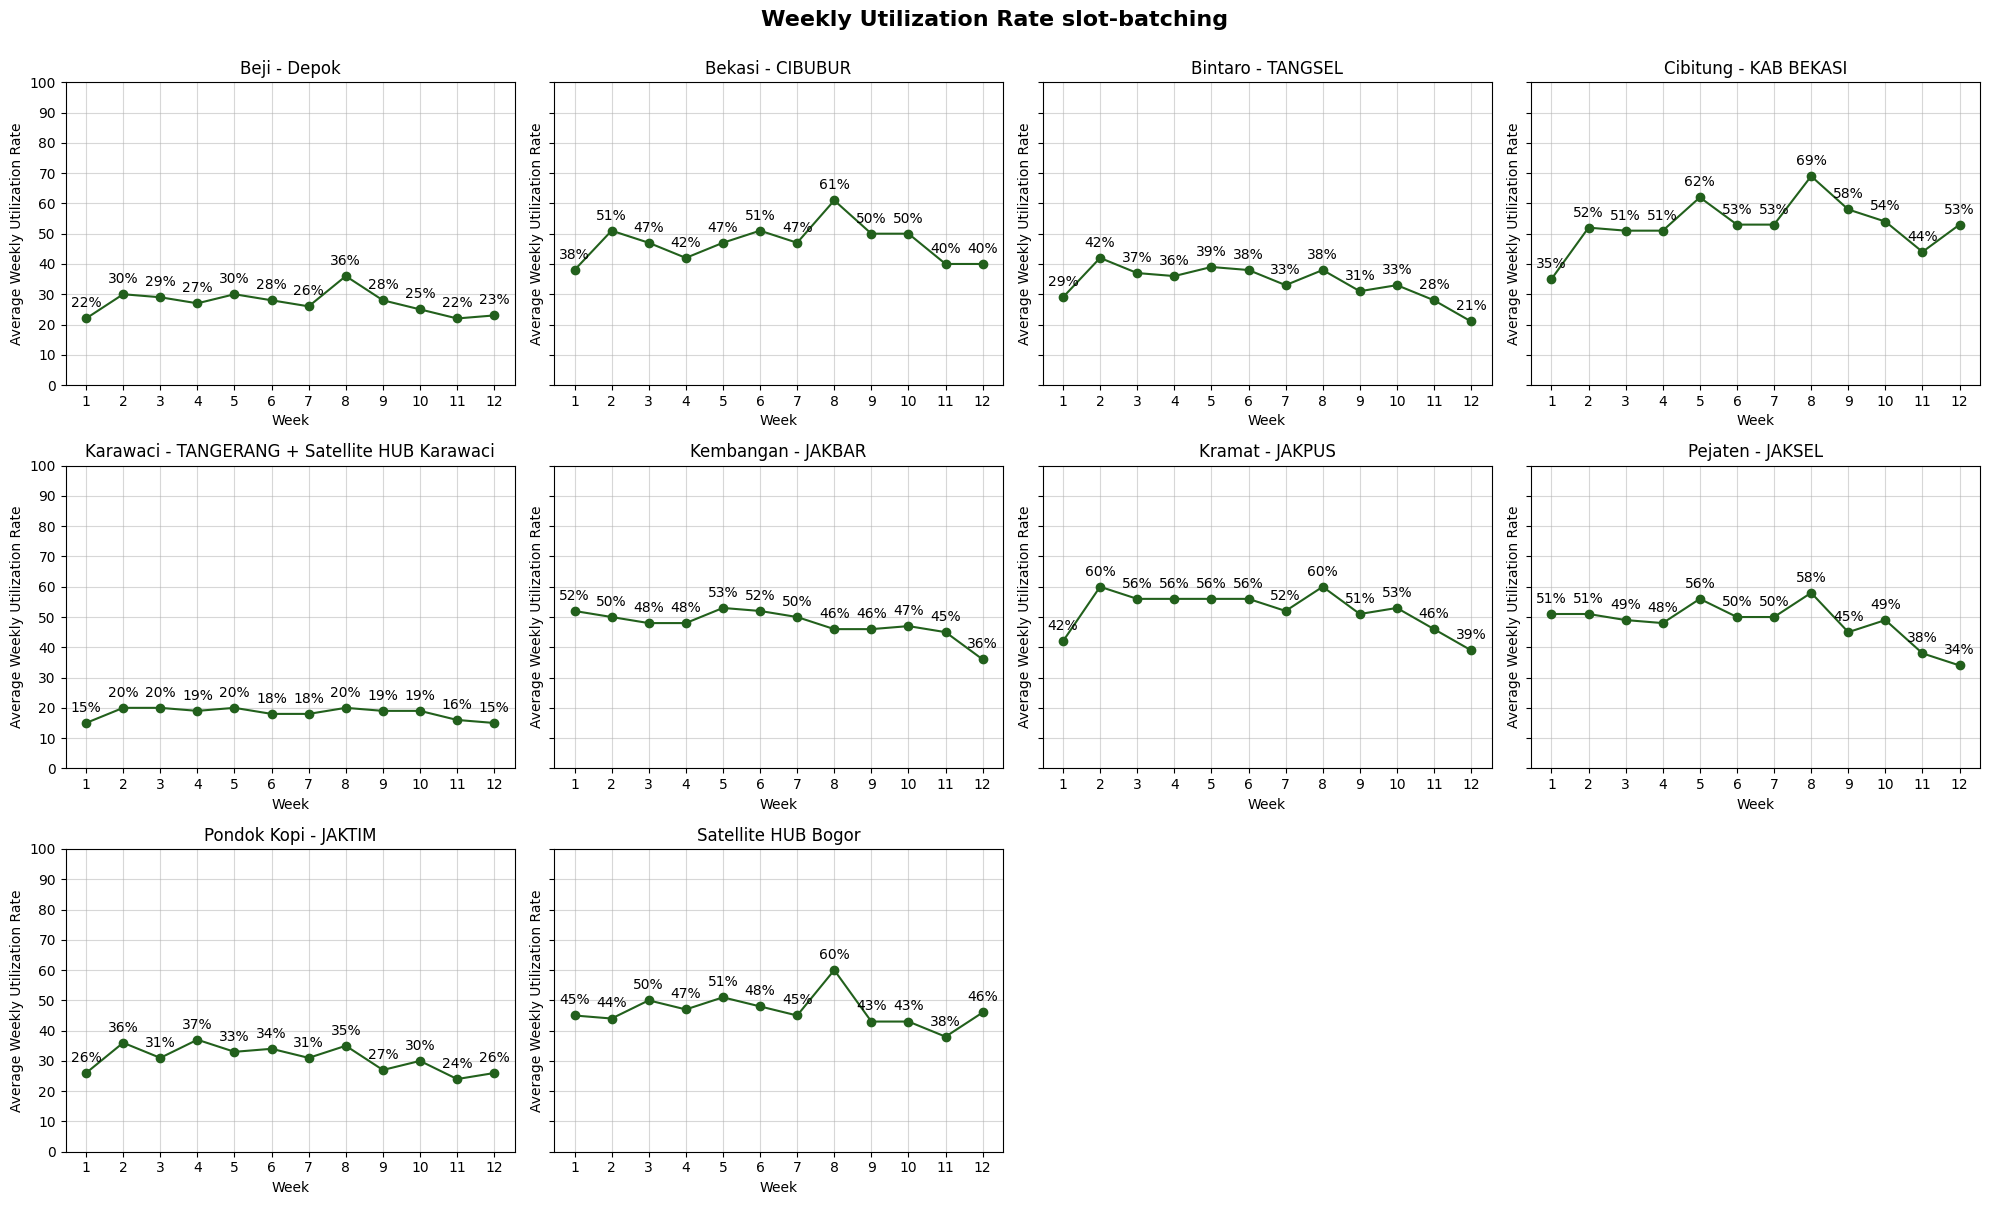

In [21]:
weekly_utilization_rate_slot_batching = utilization_rate_subplots(df=slot_batching_df, time_slot='slot-batching', time_index_column='week', start_period=1, values_column='utilization_rate', agg_method='mean')
weekly_utilization_rate_slot_batching

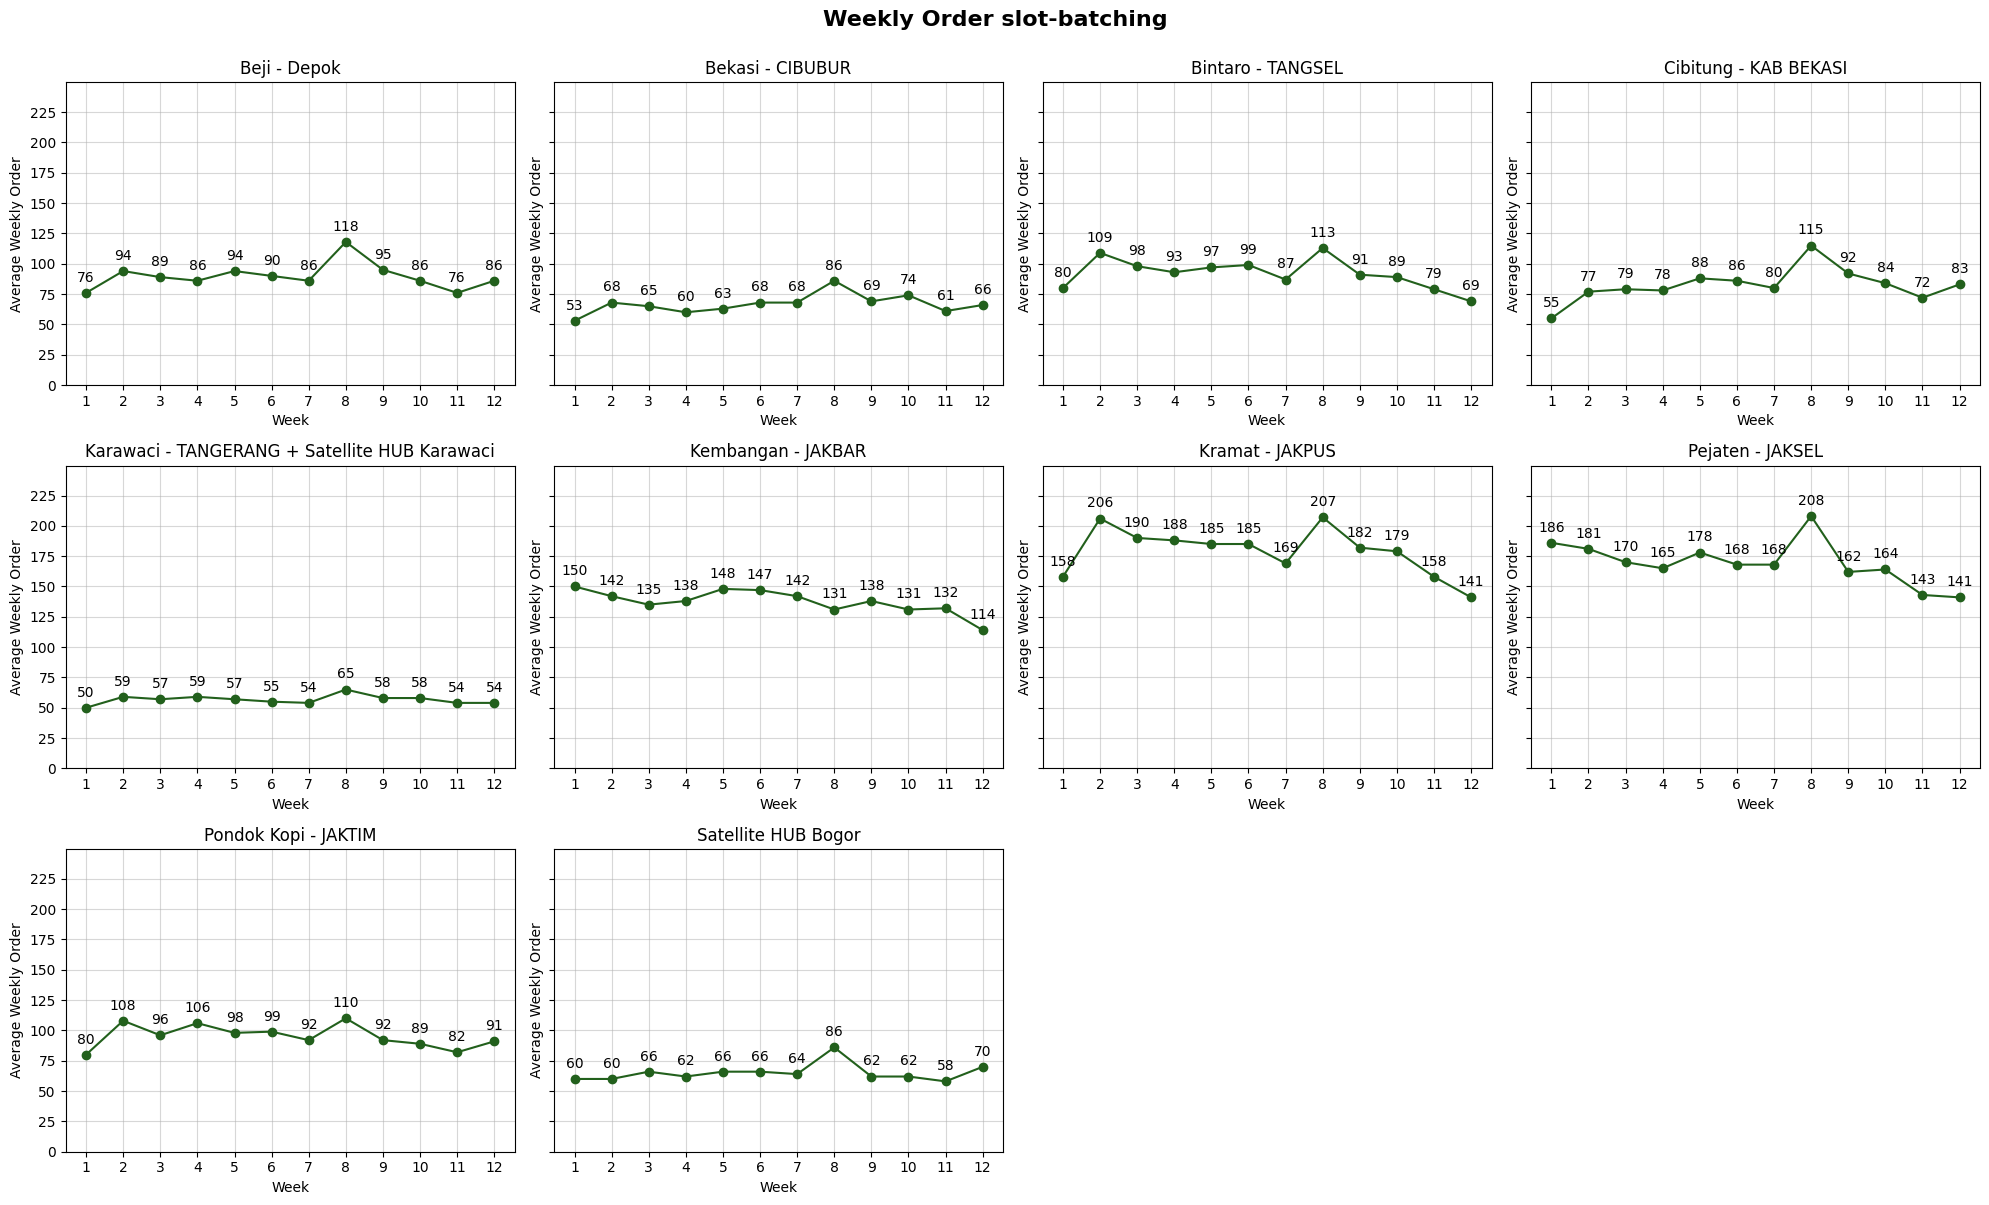

In [22]:
weekly_average_order_slot_batching = utilization_rate_subplots(df=slot_batching_df, time_slot='slot-batching', time_index_column='week', start_period=1, values_column='total_order', agg_method='mean')
weekly_average_order_slot_batching

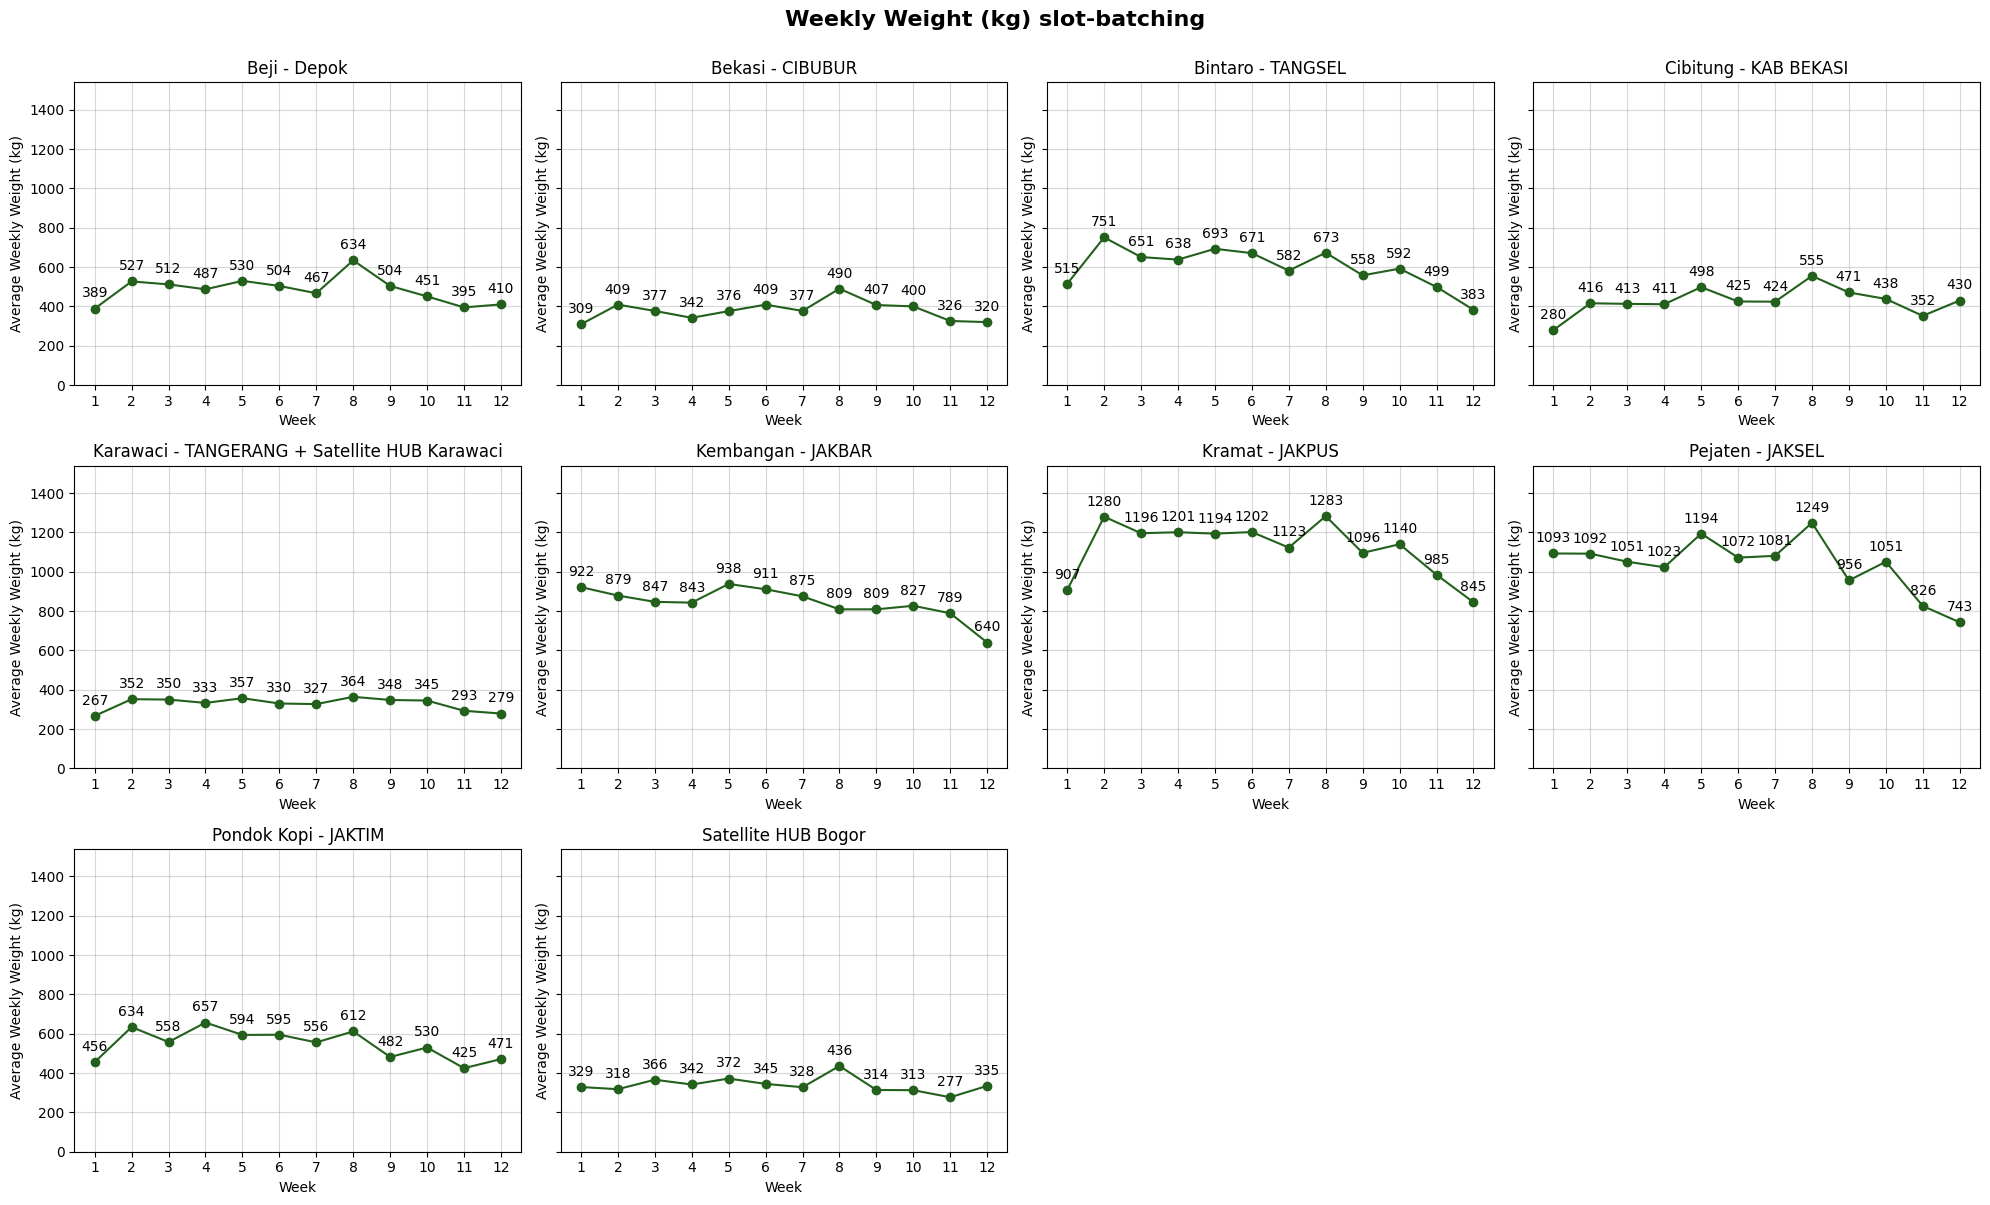

In [23]:
weekly_average_order_slot_batching = utilization_rate_subplots(df=slot_batching_df, time_slot='slot-batching', time_index_column='week', start_period=1, values_column='total_weight', agg_method='mean')
weekly_average_order_slot_batching

## Slot-2

### Filter dataframe

In [24]:
selected_columns_slot_2 = [
    'delivery_date',
    'week',
    'month',
    'hubs',
    'slot_2_total_weight_perorder',
    'order_no_slot_2'
]

selected_hubs_slot_2 = [
    'Beji - Depok',
    'Bekasi - CIBUBUR',
    'Bintaro - TANGSEL',
    'Cibitung - KAB BEKASI',
    'Karawaci - TANGERANG',
    'Kembangan - JAKBAR',
    'Kramat - JAKPUS',
    'Pondok Kopi - JAKTIM',
]

# Assigning the filtered DataFrame to 'slot_2_df'
slot_2_df = filter_dataframe(df, selected_columns_slot_2, selected_hubs_slot_2)
slot_2_df = slot_2_df.rename(columns={'order_no_slot_2': 'total_order', 'slot_2_total_weight_perorder': 'total_weight'})
display(slot_2_df)

,delivery_date,week,month,hubs,total_weight,total_order
0,2026-01-01,1,1,Beji - Depok,303,58
1,2026-01-01,1,1,Bekasi - CIBUBUR,297,53
2,2026-01-01,1,1,Bintaro - TANGSEL,300,48
3,2026-01-01,1,1,Cibitung - KAB BEKASI,250,61
4,2026-01-01,1,1,Karawaci - TANGERANG,256,46
...,...,...,...,...,...,...
923,2026-03-19,12,3,Cibitung - KAB BEKASI,134,34
924,2026-03-19,12,3,Karawaci - TANGERANG,61,20
925,2026-03-19,12,3,Kembangan - JAKBAR,0,0
926,2026-03-19,12,3,Kramat - JAKPUS,135,25


### Assign vehicle type by hubs

In [25]:
hub_to_vehicle_map = {
    'Beji - Depok': 'Blindvan',
    'Bekasi - CIBUBUR': 'Blindvan',
    'Bintaro - TANGSEL': 'Blindvan',
    'Cibitung - KAB BEKASI': 'Blindvan',
    'Karawaci - TANGERANG': 'Blindvan',
    'Kembangan - JAKBAR': 'Blindvan',
    'Kramat - JAKPUS': 'Blindvan',
    'Pondok Kopi - JAKTIM': 'Blindvan'
}

slot_2_df = assign_column_from_map(slot_2_df, 'hubs', 'vehicle_type', hub_to_vehicle_map, 'NAN')

slot_2_df

,delivery_date,week,month,hubs,total_weight,total_order,vehicle_type
0,2026-01-01,1,1,Beji - Depok,303,58,Blindvan
1,2026-01-01,1,1,Bekasi - CIBUBUR,297,53,Blindvan
2,2026-01-01,1,1,Bintaro - TANGSEL,300,48,Blindvan
3,2026-01-01,1,1,Cibitung - KAB BEKASI,250,61,Blindvan
4,2026-01-01,1,1,Karawaci - TANGERANG,256,46,Blindvan
...,...,...,...,...,...,...,...
923,2026-03-19,12,3,Cibitung - KAB BEKASI,134,34,Blindvan
924,2026-03-19,12,3,Karawaci - TANGERANG,61,20,Blindvan
925,2026-03-19,12,3,Kembangan - JAKBAR,0,0,Blindvan
926,2026-03-19,12,3,Kramat - JAKPUS,135,25,Blindvan


### Assign vehicle max tonnage by vehicle type

In [26]:
vehicle_to_tonnage_map = {
    'Blindvan': 720,
    'Vanbox': 800,
    'CDE': 1750,
    'CDD': 2125
}

slot_2_df = assign_column_from_map(slot_2_df, 'vehicle_type', 'max_tonnage', vehicle_to_tonnage_map, 0)

slot_2_df

,delivery_date,week,month,hubs,total_weight,total_order,vehicle_type,max_tonnage
0,2026-01-01,1,1,Beji - Depok,303,58,Blindvan,720
1,2026-01-01,1,1,Bekasi - CIBUBUR,297,53,Blindvan,720
2,2026-01-01,1,1,Bintaro - TANGSEL,300,48,Blindvan,720
3,2026-01-01,1,1,Cibitung - KAB BEKASI,250,61,Blindvan,720
4,2026-01-01,1,1,Karawaci - TANGERANG,256,46,Blindvan,720
...,...,...,...,...,...,...,...,...
923,2026-03-19,12,3,Cibitung - KAB BEKASI,134,34,Blindvan,720
924,2026-03-19,12,3,Karawaci - TANGERANG,61,20,Blindvan,720
925,2026-03-19,12,3,Kembangan - JAKBAR,0,0,Blindvan,720
926,2026-03-19,12,3,Kramat - JAKPUS,135,25,Blindvan,720


### Calculate utilization rate

In [27]:
slot_2_df = calculate_utilization_rate(df=slot_2_df, weight_column='total_weight', max_tonnage_column='max_tonnage', new_column_name='utilization_rate')

### Subplots

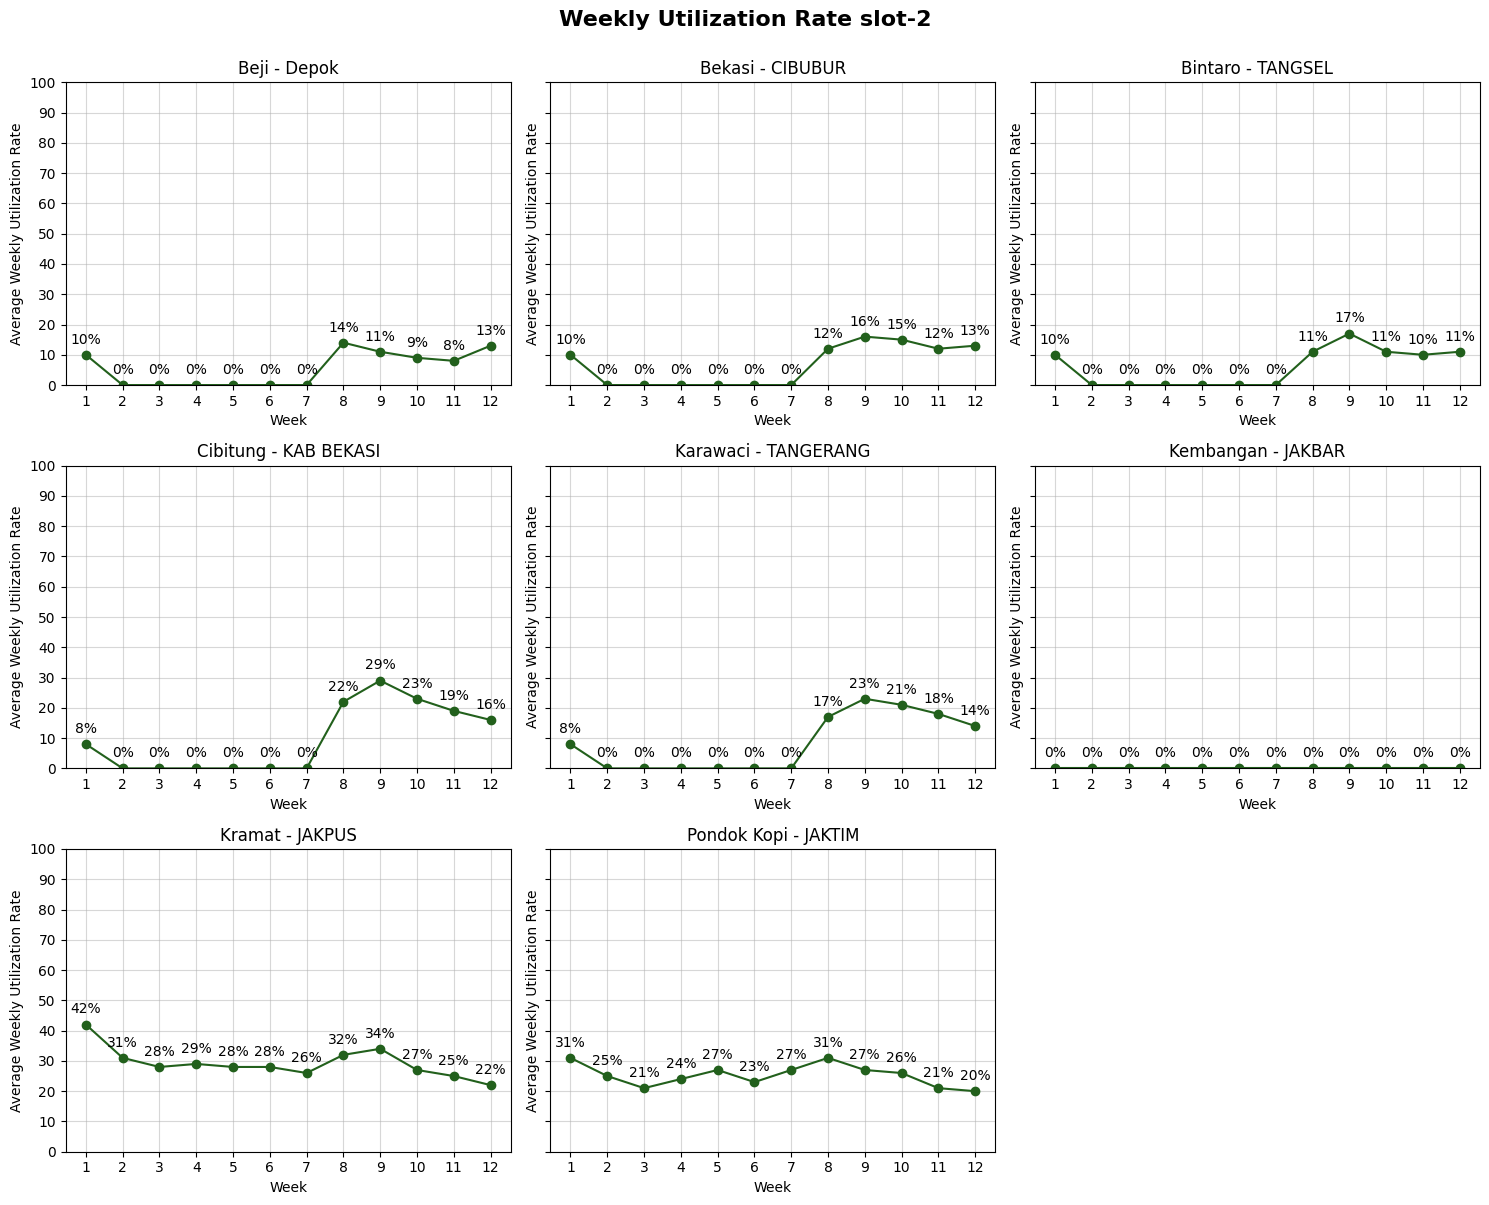

In [28]:
weekly_utilization_rate_slot_2 = utilization_rate_subplots(df=slot_2_df, time_slot='slot-2', time_index_column='week', start_period=1, values_column='utilization_rate', agg_method='mean')
weekly_utilization_rate_slot_2

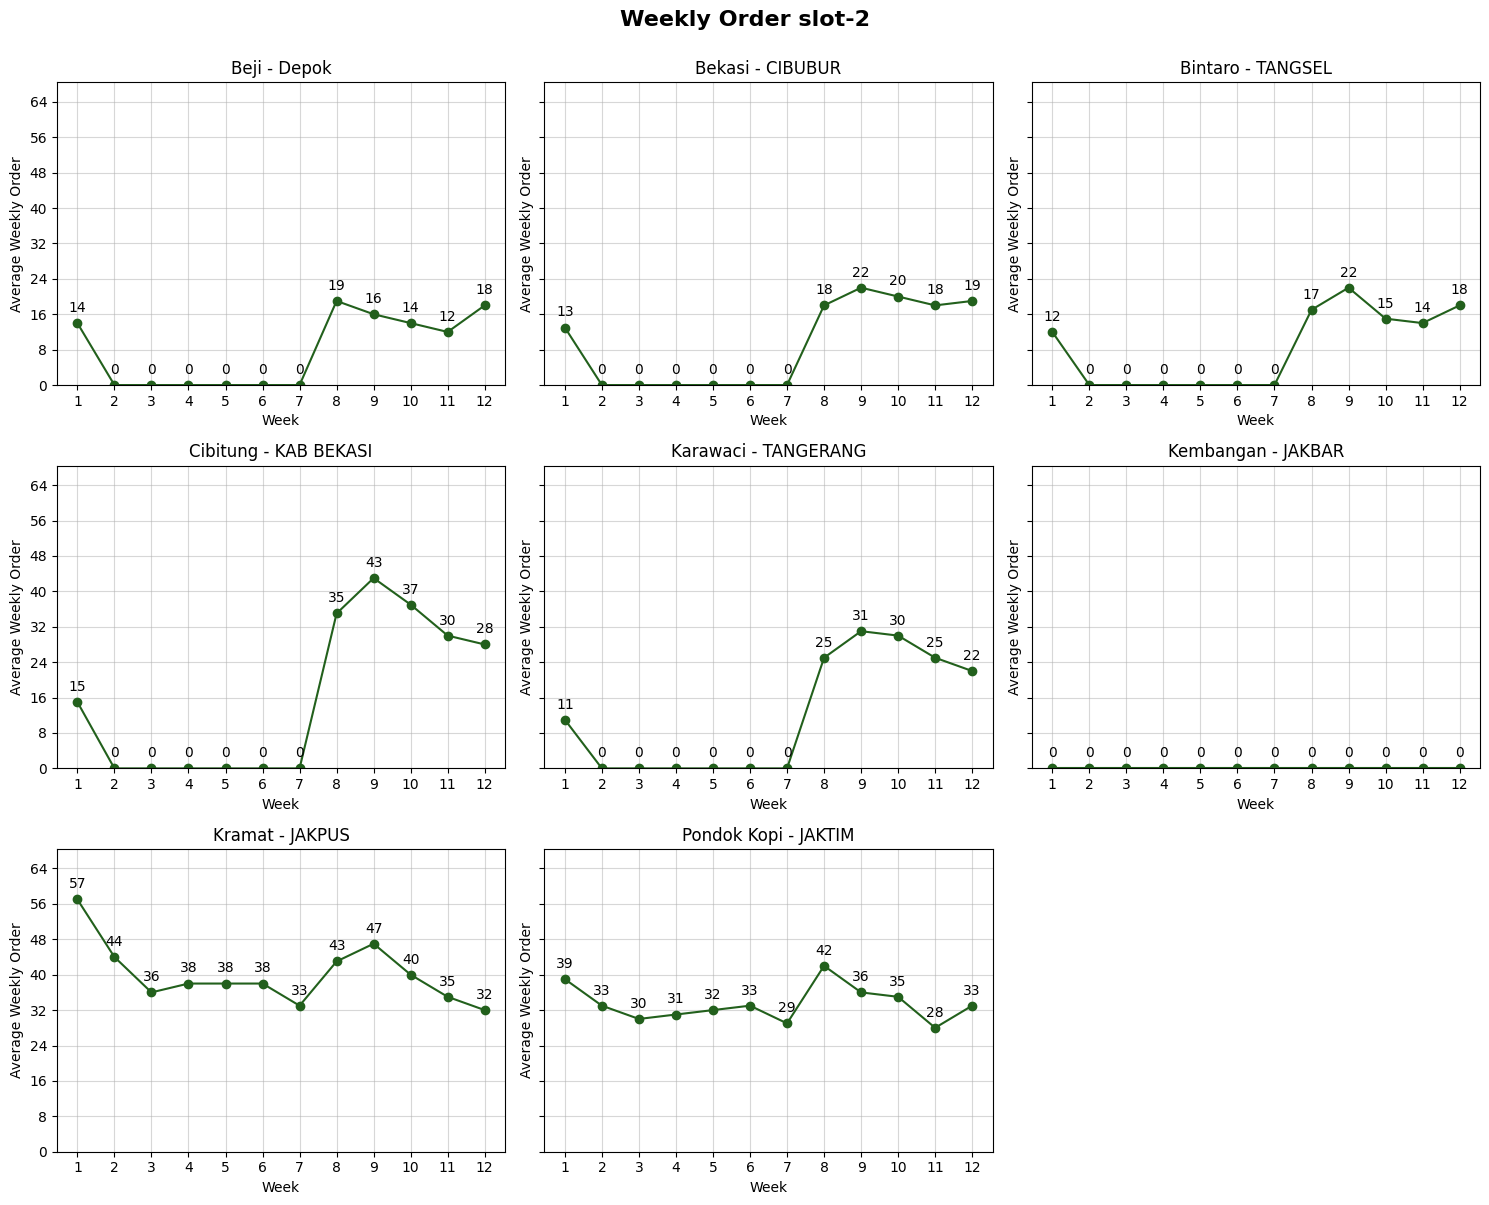

In [29]:
weekly_utilization_rate_slot_2 = utilization_rate_subplots(df=slot_2_df, time_slot='slot-2', time_index_column='week', start_period=1, values_column='total_order', agg_method='mean')
weekly_utilization_rate_slot_2

## Slot-Sameday

### Filter dataframe

### Assign vehicle type by hubs

In [30]:
selected_columns_slot_sameday = [
    'delivery_date',
    'week',
    'month',
    'hubs',
    'slot_sameday_total_weight_perorder',
    'order_no_slot_sameday'
]

selected_hubs_slot_sameday = [
    'Beji - Depok',
    'Bekasi - CIBUBUR',
    'Bintaro - TANGSEL',
    'Cibitung - KAB BEKASI',
    'Karawaci - TANGERANG',
    'Kembangan - JAKBAR',
    'Kramat - JAKPUS',
    'Pondok Kopi - JAKTIM'
]

# Assigning the filtered DataFrame to 'slot_sameday_df'
slot_sameday_df = filter_dataframe(df, selected_columns_slot_sameday, selected_hubs_slot_sameday)
slot_sameday_df = slot_sameday_df.rename(columns={'order_no_slot_sameday': 'total_order', 'slot_sameday_total_weight_perorder': 'total_weight'})
display(slot_sameday_df)

,delivery_date,week,month,hubs,total_weight,total_order
0,2026-01-01,1,1,Beji - Depok,86,14
1,2026-01-01,1,1,Bekasi - CIBUBUR,83,16
2,2026-01-01,1,1,Bintaro - TANGSEL,29,5
3,2026-01-01,1,1,Cibitung - KAB BEKASI,126,24
4,2026-01-01,1,1,Karawaci - TANGERANG,78,13
...,...,...,...,...,...,...
923,2026-03-19,12,3,Cibitung - KAB BEKASI,0,0
924,2026-03-19,12,3,Karawaci - TANGERANG,0,0
925,2026-03-19,12,3,Kembangan - JAKBAR,0,0
926,2026-03-19,12,3,Kramat - JAKPUS,154,30


### Assign vehicle max tonnage by vehicle type

In [31]:
hub_to_vehicle_map = {
    'Beji - Depok': 'Blindvan',
    'Bekasi - CIBUBUR': 'Blindvan',
    'Bintaro - TANGSEL': 'Blindvan',
    'Cibitung - KAB BEKASI': 'Blindvan',
    'Karawaci - TANGERANG': 'Blindvan',
    'Kembangan - JAKBAR': 'Blindvan',
    'Kramat - JAKPUS': 'Blindvan',
    'Pondok Kopi - JAKTIM': 'Blindvan'
}

slot_sameday_df = assign_column_from_map(slot_sameday_df, 'hubs', 'vehicle_type', hub_to_vehicle_map, 'NAN')

slot_sameday_df

,delivery_date,week,month,hubs,total_weight,total_order,vehicle_type
0,2026-01-01,1,1,Beji - Depok,86,14,Blindvan
1,2026-01-01,1,1,Bekasi - CIBUBUR,83,16,Blindvan
2,2026-01-01,1,1,Bintaro - TANGSEL,29,5,Blindvan
3,2026-01-01,1,1,Cibitung - KAB BEKASI,126,24,Blindvan
4,2026-01-01,1,1,Karawaci - TANGERANG,78,13,Blindvan
...,...,...,...,...,...,...,...
923,2026-03-19,12,3,Cibitung - KAB BEKASI,0,0,Blindvan
924,2026-03-19,12,3,Karawaci - TANGERANG,0,0,Blindvan
925,2026-03-19,12,3,Kembangan - JAKBAR,0,0,Blindvan
926,2026-03-19,12,3,Kramat - JAKPUS,154,30,Blindvan


In [32]:
vehicle_to_tonnage_map = {
    'Blindvan': 720,
    'Vanbox': 800,
    'CDE': 1750,
    'CDD': 2125
}

slot_sameday_df = assign_column_from_map(slot_sameday_df, 'vehicle_type', 'max_tonnage', vehicle_to_tonnage_map, 0)

slot_sameday_df

,delivery_date,week,month,hubs,total_weight,total_order,vehicle_type,max_tonnage
0,2026-01-01,1,1,Beji - Depok,86,14,Blindvan,720
1,2026-01-01,1,1,Bekasi - CIBUBUR,83,16,Blindvan,720
2,2026-01-01,1,1,Bintaro - TANGSEL,29,5,Blindvan,720
3,2026-01-01,1,1,Cibitung - KAB BEKASI,126,24,Blindvan,720
4,2026-01-01,1,1,Karawaci - TANGERANG,78,13,Blindvan,720
...,...,...,...,...,...,...,...,...
923,2026-03-19,12,3,Cibitung - KAB BEKASI,0,0,Blindvan,720
924,2026-03-19,12,3,Karawaci - TANGERANG,0,0,Blindvan,720
925,2026-03-19,12,3,Kembangan - JAKBAR,0,0,Blindvan,720
926,2026-03-19,12,3,Kramat - JAKPUS,154,30,Blindvan,720


### Calculate utilization rate

In [33]:
slot_sameday_df = calculate_utilization_rate(df=slot_sameday_df, weight_column='total_weight', max_tonnage_column='max_tonnage', new_column_name='utilization_rate')

### Subplots

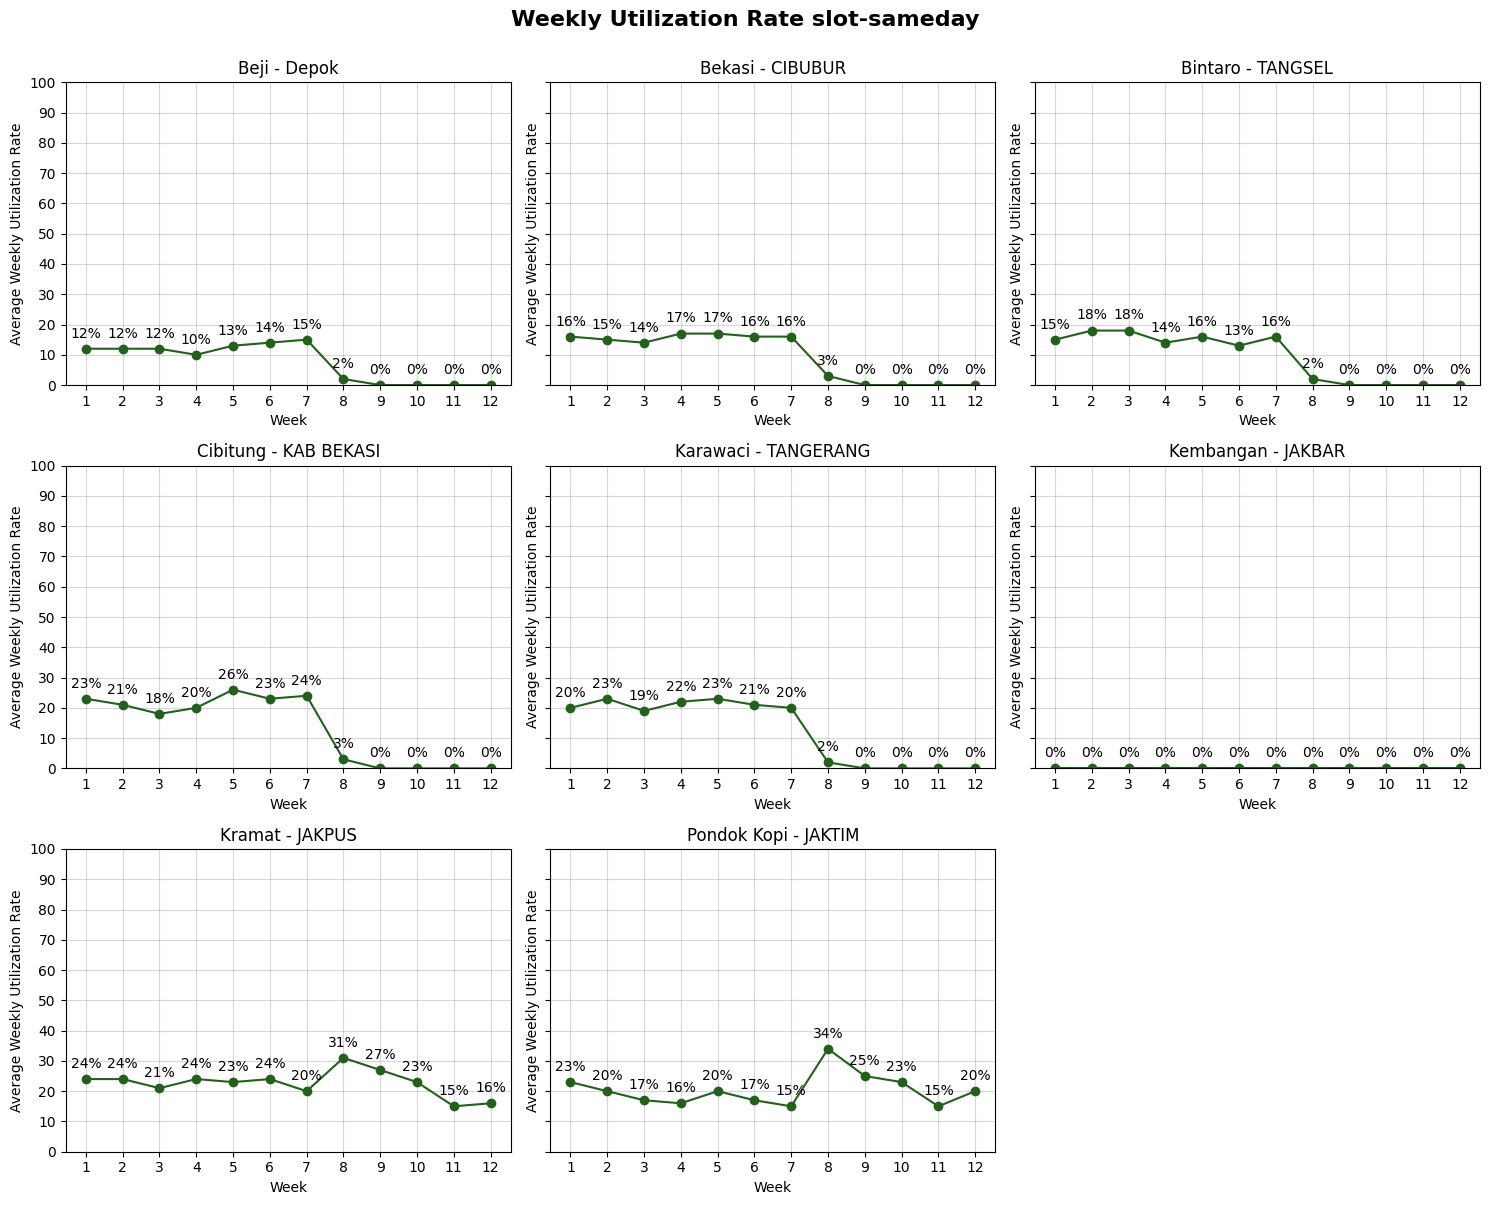

In [34]:
weekly_utilization_rate_slot_sameday = utilization_rate_subplots(df=slot_sameday_df, time_slot='slot-sameday', time_index_column='week', start_period=1, values_column='utilization_rate', agg_method='mean')
weekly_utilization_rate_slot_sameday

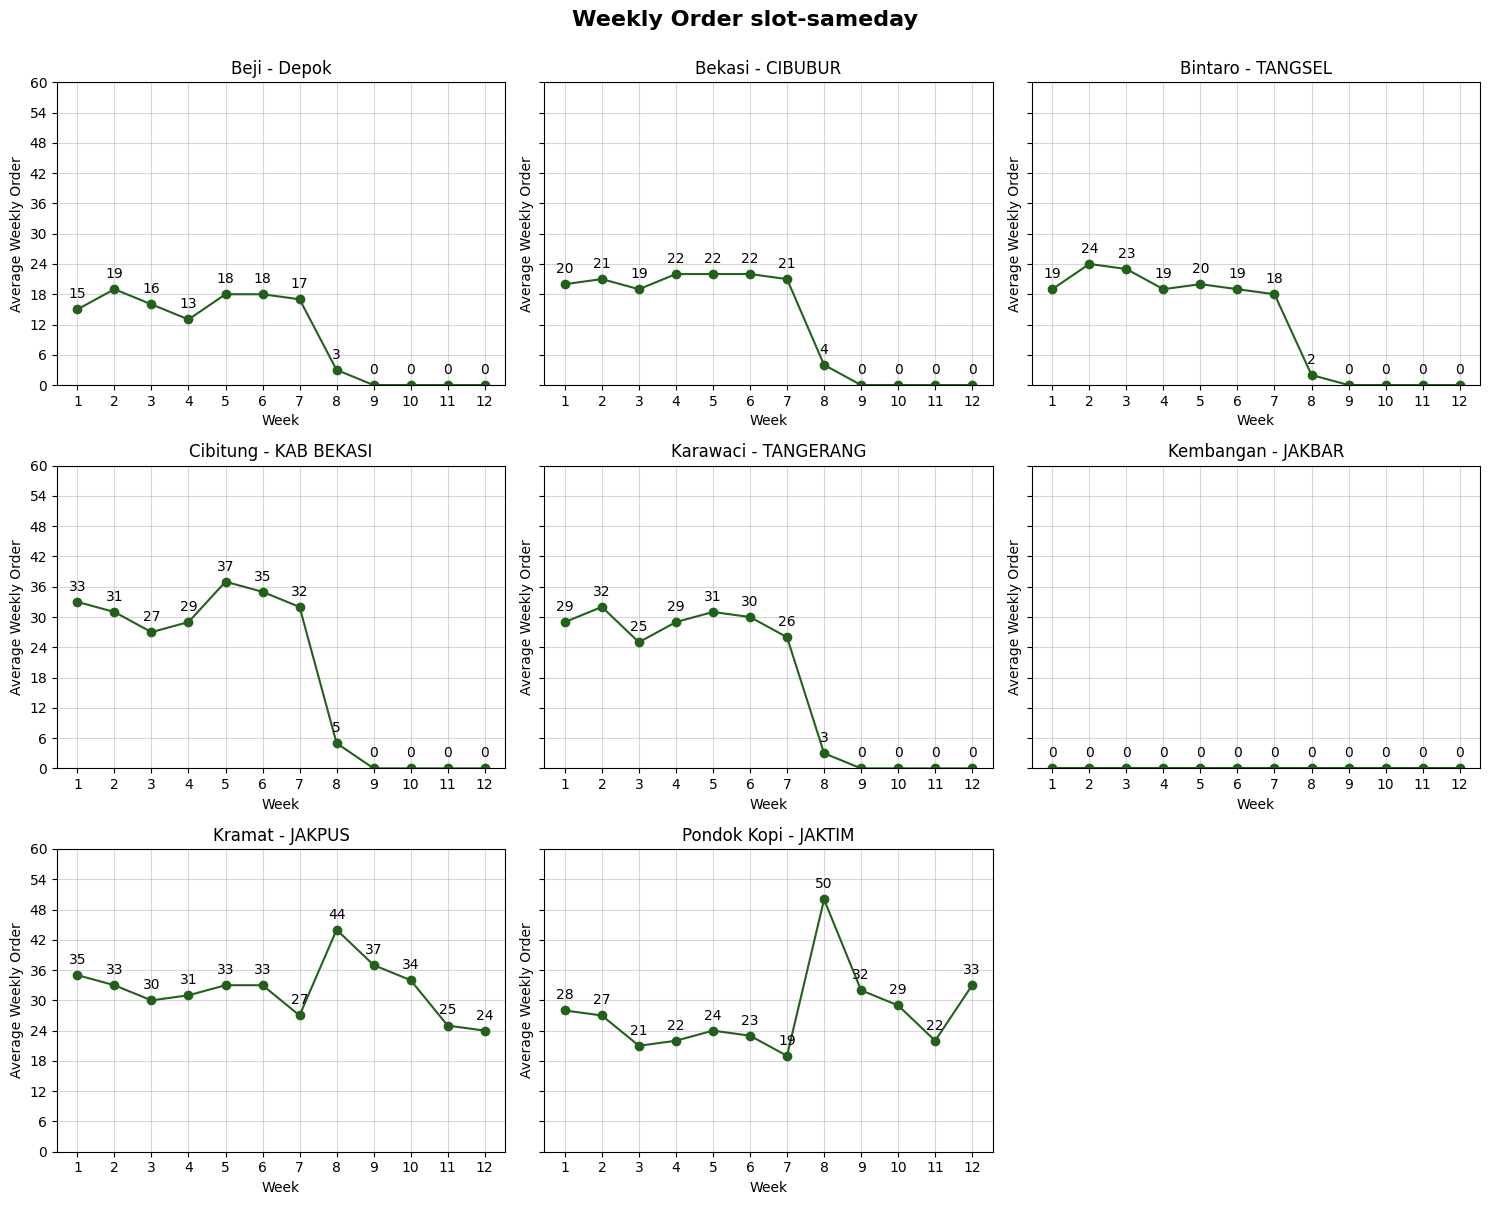

In [35]:
weekly_utilization_rate_slot_sameday = utilization_rate_subplots(df=slot_sameday_df, time_slot='slot-sameday', time_index_column='week', start_period=1, values_column='total_order', agg_method='mean')
weekly_utilization_rate_slot_sameday

# Multiple Subplots

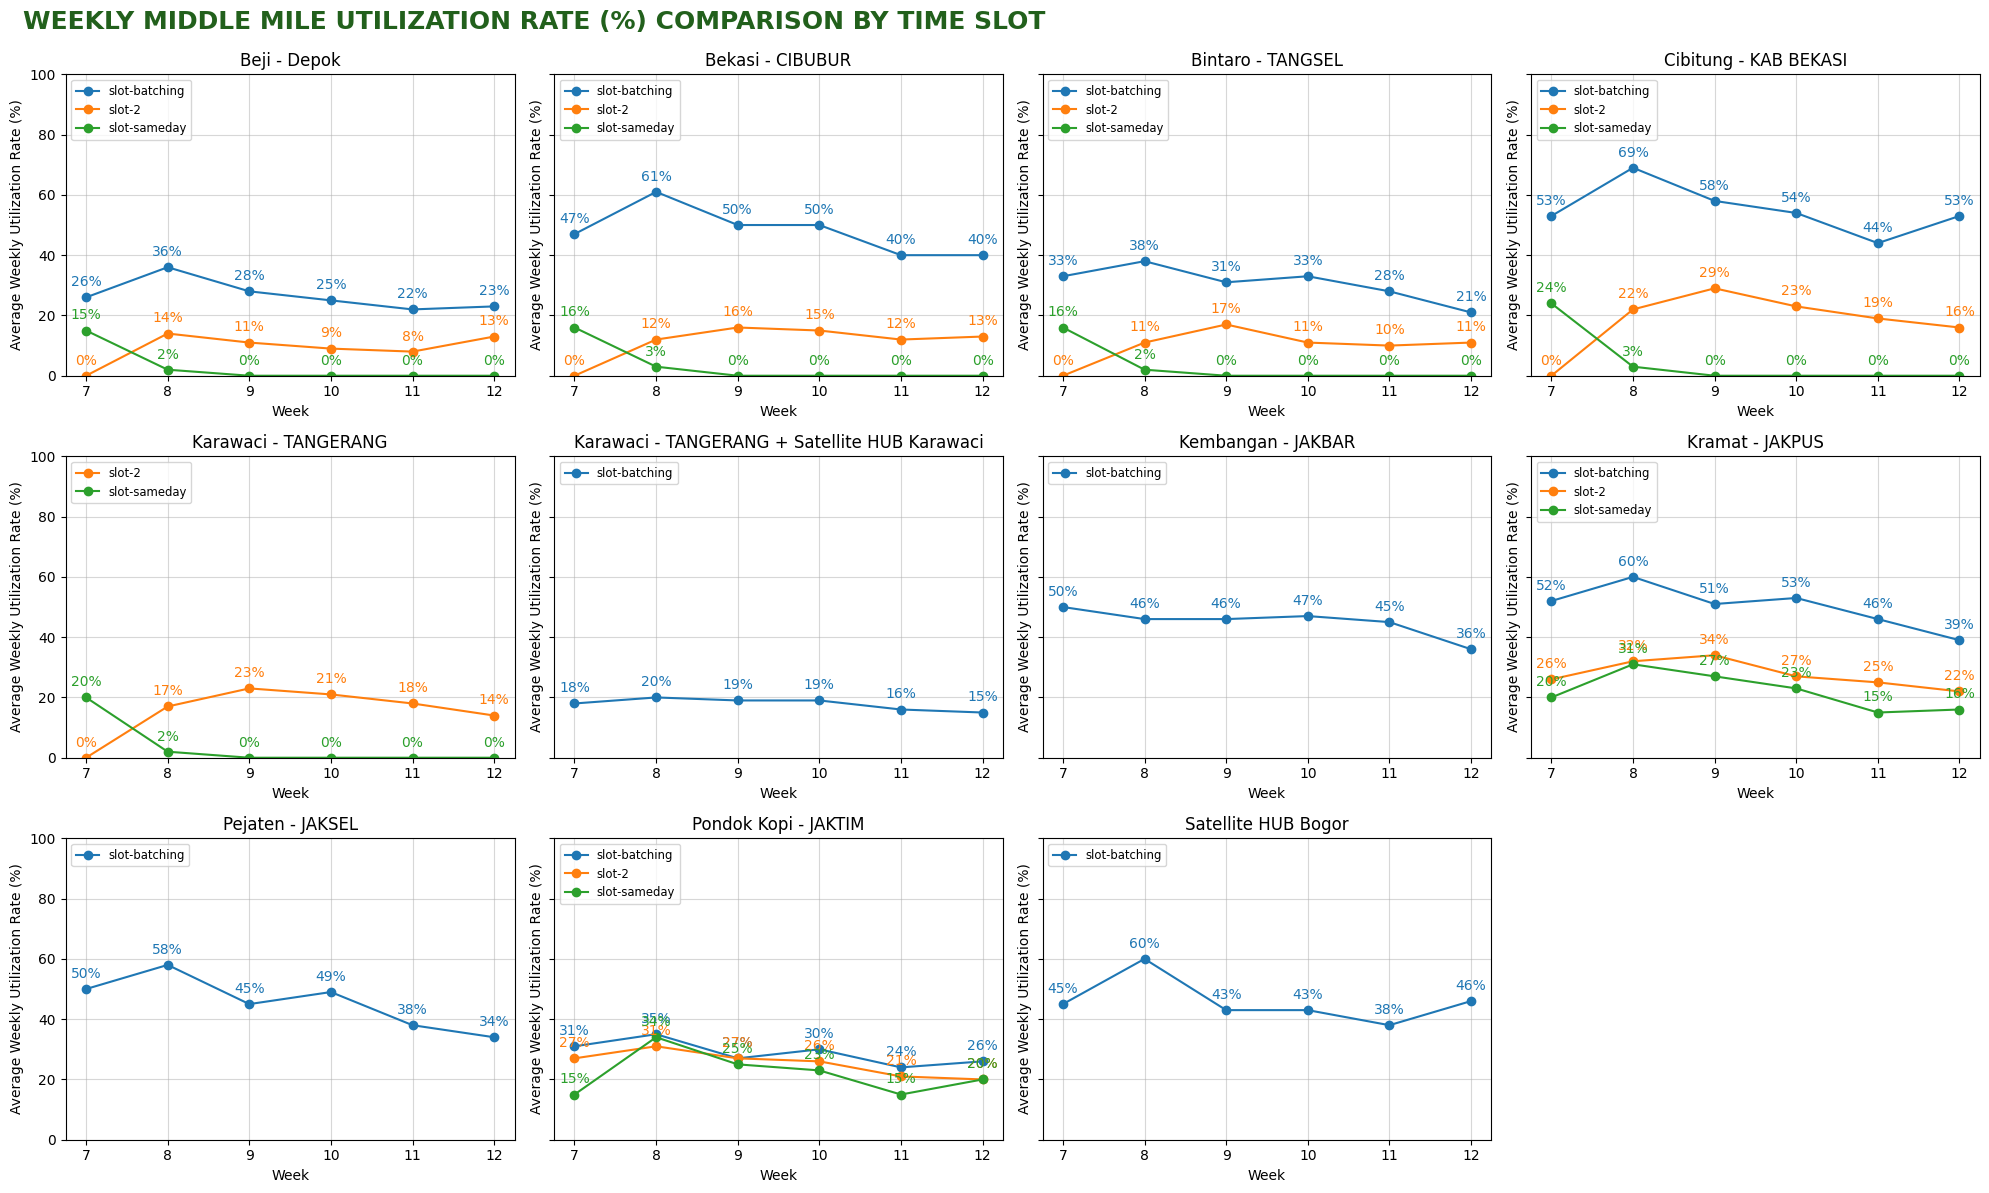

In [36]:
dataframes_for_comparison = {
    'slot-batching': slot_batching_df,
    'slot-2': slot_2_df,
    'slot-sameday': slot_sameday_df
}

plot_multi_timeslot_utilization(
    dataframes_dict=dataframes_for_comparison,
    time_index_column='week',
    time_delta=6,
    values_column='utilization_rate',
    agg_method='mean'
)

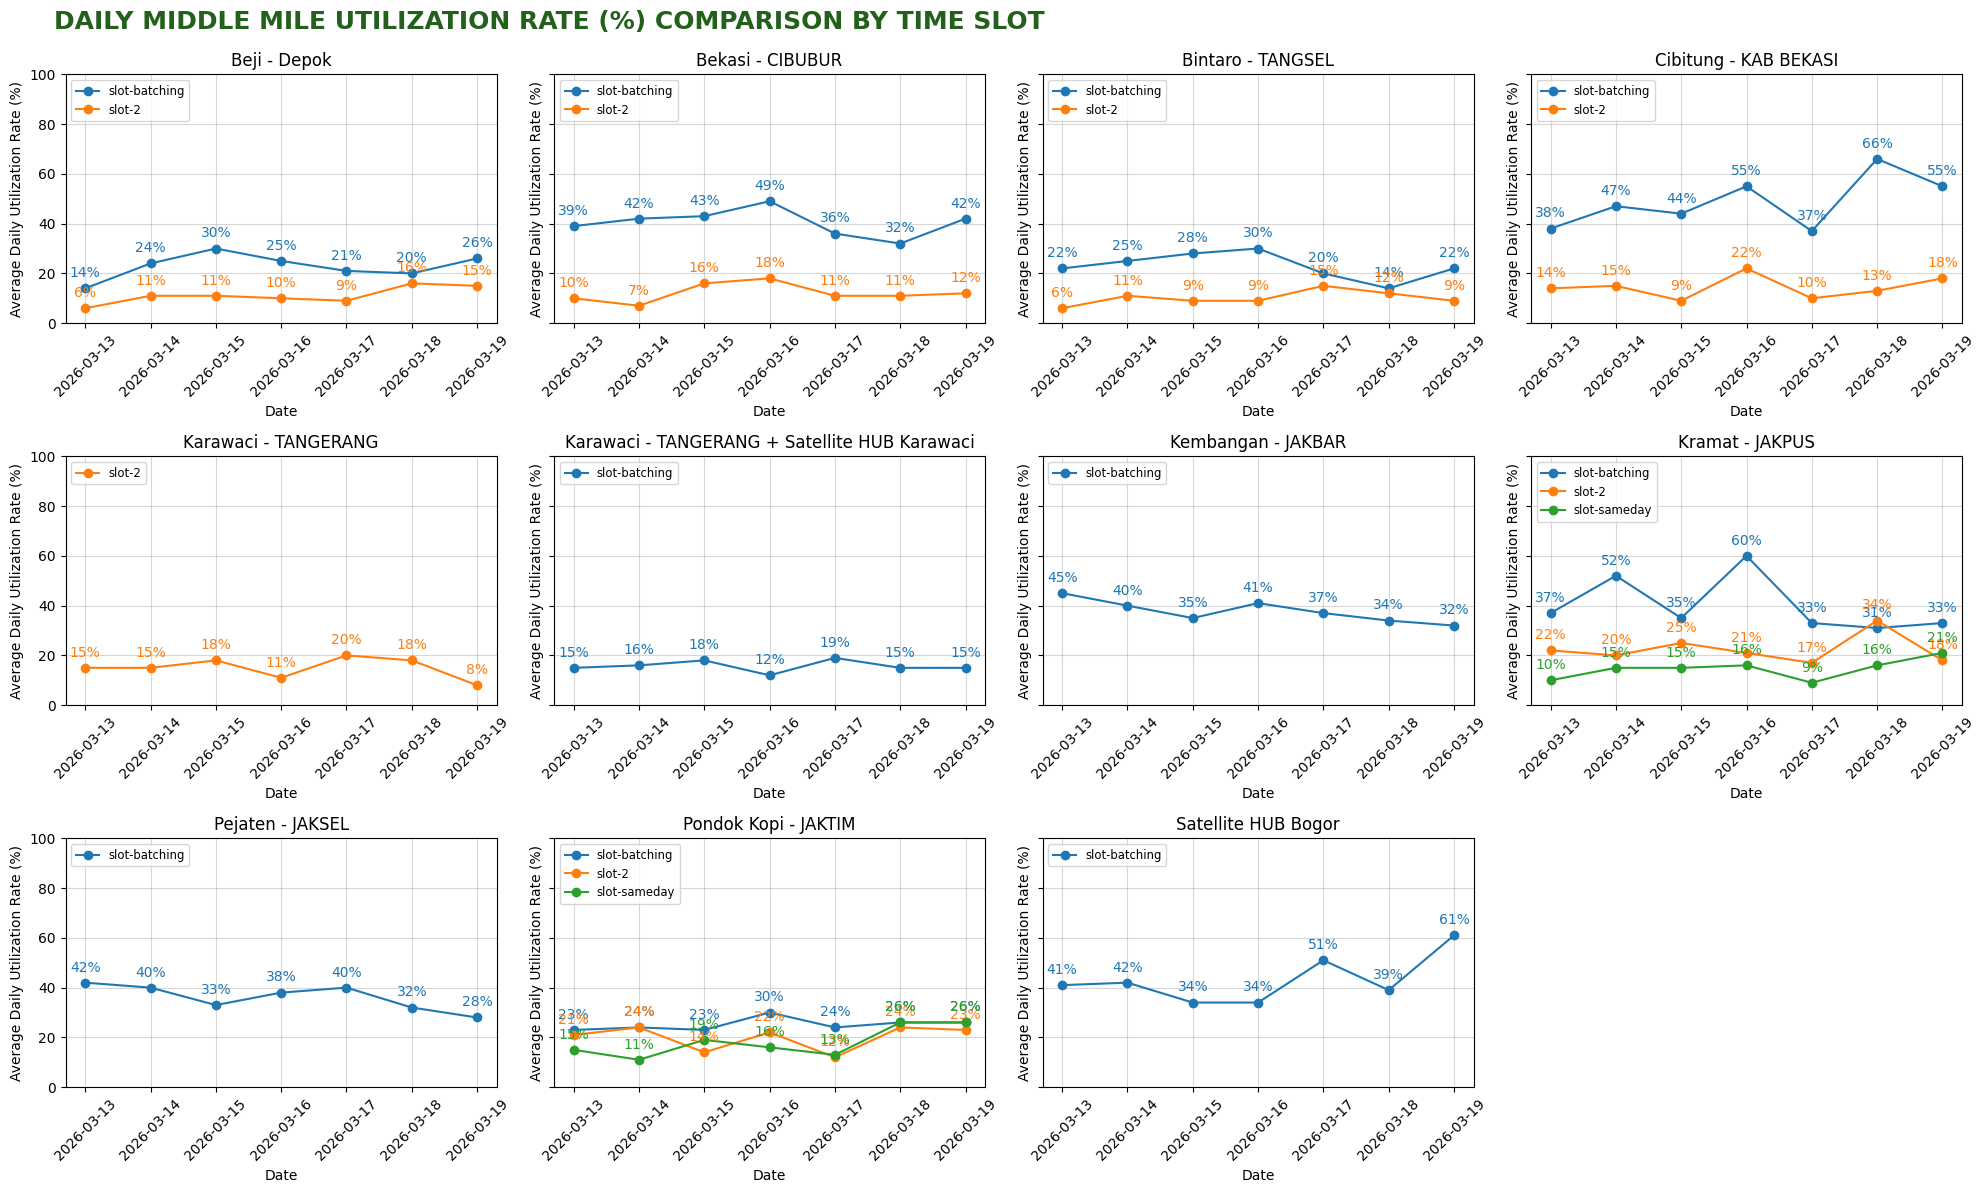

In [37]:
dataframes_for_comparison = {
    'slot-batching': slot_batching_df,
    'slot-2': slot_2_df,
    'slot-sameday': slot_sameday_df
}

plot_multi_timeslot_utilization(
    dataframes_dict=dataframes_for_comparison,
    time_index_column='delivery_date',
    time_delta=7,
    values_column='utilization_rate',
    agg_method='mean'
)